# ICA Group B — Convolutional Neural Network on CIFAR-10
## Data-Driven Science and Engineering

**Your task (45 min):** Build, train, and evaluate a CNN image classifier.  
**Then (10 min):** Prepare a whiteboard lecture for the other groups using the template at the bottom.

---
### What is a CNN?

A CNN (Convolutional Neural Network) learns to detect **local spatial patterns** in images.  
Instead of fully-connected layers (which treat every pixel independently), CNNs slide a small *filter* (kernel) across the image to detect features like edges, textures, and shapes.

```
Image  ──►  Conv+ReLU  ──►  Pool  ──►  Conv+ReLU  ──►  Pool  ──►  Flatten  ──►  FC  ──►  Class
         (detect edges)  (shrink)  (detect shapes)  (shrink)
```

**Two key ideas:**
- **Parameter sharing:** the same filter is applied everywhere → far fewer weights than a dense layer  
- **Local connectivity:** each neuron sees only a small patch (receptive field), not the whole image

**Why CIFAR-10?**  
10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.  
32×32 RGB images — small enough to train on CPU in minutes, rich enough to be interesting.

---
## Step 1 — Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

Using device: cpu


---
## Step 2 — Load CIFAR-10

We use a **subset** (8,000 train / 2,000 test) so training finishes quickly on CPU.  

**Data augmentation** is applied to the training set:  
- Random horizontal flip — the same object flipped left-right should be the same class  
- Random crop — the classifier should be position-invariant  

The test set uses only `ToTensor` + normalisation — no augmentation (we want a fair evaluation).

In [2]:
# Normalisation values are the per-channel mean and std of CIFAR-10
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

full_train = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
full_test  = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# Use a subset for speed on CPU
train_dataset = Subset(full_train, range(8000))
test_dataset  = Subset(full_test,  range(2000))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=0)

x_sample, y_sample = next(iter(train_loader))
print(f"Batch shape: {x_sample.shape}")   # (128, 3, 32, 32)  ← (batch, channels, H, W)
print(f"Labels: {[CLASSES[y] for y in y_sample[:8]]}")

c:\Users\l-a-c\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Batch shape: torch.Size([128, 3, 32, 32])
Labels: ['cat', 'deer', 'deer', 'bird', 'bird', 'cat', 'truck', 'cat']


---
## Step 3 — Visualise Some Training Images

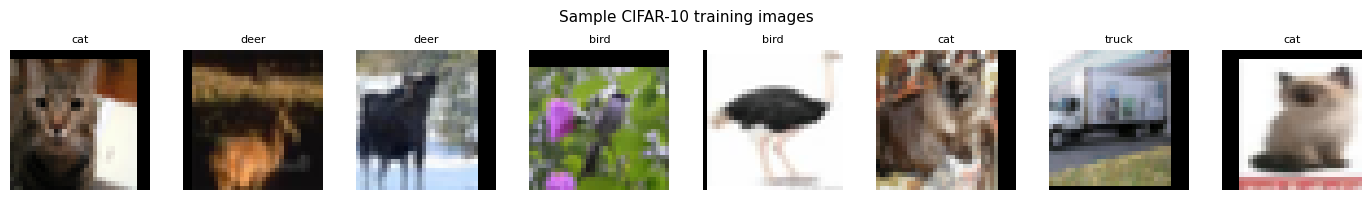

In [3]:
def denorm(img_tensor):
    """Undo normalisation for display."""
    mean = torch.tensor(MEAN).view(3,1,1)
    std  = torch.tensor(STD).view(3,1,1)
    return (img_tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i in range(8):
    img = denorm(x_sample[i]).permute(1, 2, 0).numpy()  # (C,H,W) → (H,W,C)
    axes[i].imshow(img)
    axes[i].set_title(CLASSES[y_sample[i].item()], fontsize=8)
    axes[i].axis('off')
plt.suptitle('Sample CIFAR-10 training images', fontsize=11)
plt.tight_layout(); plt.show()

---
## Step 4 — Define the CNN Architecture

Our CNN has two convolutional blocks followed by two fully-connected layers.

**Full architecture:**
```
Input (3×32×32)
  │
  ▼  Conv2d(3, out1, kernel_size=k1)  →  ReLU  →  MaxPool2d(2)
  │  Feature maps: out1 × ? × ?
  │
  ▼  Conv2d(out1, out2, kernel_size=k2)  →  ReLU  →  MaxPool2d(2)
  │  Feature maps: out2 × ? × ?
  │
  ▼  Flatten
  │
  ▼  Linear(out2 × 6 × 6, 256)  →  ReLU  →  Dropout(0.4)
  │
  ▼  Linear(256, 10)   ← 10 classes, no activation (CrossEntropyLoss handles it)
```

✏️ **Your job:** Fill in `out1`, `out2`, `k1`, `k2`.  
Start with `out1=32, out2=64, k1=3, k2=3` — small filters, doubling feature maps.  

> **Kernel size:** a 3×3 filter looks at a 3×3 patch. Larger kernels see more context but cost more.  
> **Out channels:** how many different filters to learn at each layer.

In [71]:
# ✏️ FILL IN: convolutional layer parameters
OUT1 = 1028  # number of filters in first conv layer  (try 32)
OUT2 = 32  # number of filters in second conv layer (try 64)
K1   = 3   # kernel (filter) size for first conv    (try 3)
K2   = 3  # kernel (filter) size for second conv   (try 3)

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # ── Convolutional blocks ────────────────────────────────────────────
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3,    OUT1, kernel_size=K1, padding=K1//2),  # (3,32,32) → (OUT1,32,32)
            nn.ReLU(),
            nn.MaxPool2d(2)   # halve spatial dims: (OUT1,32,32) → (OUT1,16,16)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(OUT1, OUT2, kernel_size=K2, padding=K2//2),  # → (OUT2,16,16)
            nn.ReLU(),
            nn.MaxPool2d(2)   # → (OUT2,8,8)
        )

        # ── Fully-connected head ────────────────────────────────────────────
        # After two MaxPool2d(2) operations: 32→16→8
        self.classifier = nn.Sequential(
            nn.Flatten(),               # (OUT2,8,8) → (OUT2*8*8,)
            nn.Linear(OUT2 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),            # randomly zero 40% of neurons during training
            nn.Linear(256, 10)          # 10 class scores (logits)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x   # shape: (batch, 10)

model = SmallCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")
print(model)

Total parameters: 851,994
SmallCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 1028, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(1028, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


---
## Step 5 — Loss, Optimizer, and Learning Rate

For multi-class classification we use **CrossEntropyLoss**.  
It combines a softmax (turns logits into probabilities) and a negative log-likelihood loss.

✏️ **Your job:** Fill in the learning rate for the Adam optimizer.  
A good starting point for Adam on image classifiers is `1e-3`.

In [72]:
criterion = nn.CrossEntropyLoss()   # correct for multi-class classification

# ✏️ FILL IN: learning rate
LR = 1e-3  # try 1e-3

optimizer = optim.Adam(model.parameters(), lr=LR)

print(f"Loss: {criterion}")
print(f"Optimizer: Adam  lr={LR}")

Loss: CrossEntropyLoss()
Optimizer: Adam  lr=0.001


---
## Step 6 — Training and Validation Loop

Both the training and evaluation loops are provided.  
Read through them — the pattern is the same as Notebook A.

Note: during **evaluation** we call `model.eval()` and `torch.no_grad()`.  
`eval()` disables Dropout (we want deterministic predictions at test time).  
`no_grad()` tells PyTorch not to track gradients — faster and uses less memory.

In [73]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)               # (batch, 10)
        loss   = criterion(logits, y)   # CrossEntropyLoss wants (logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += x.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            correct += (logits.argmax(1) == y).sum().item()
            total   += x.size(0)
    return correct / total

EPOCHS = 8
train_losses, train_accs, test_accs = [], [], []

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    te_acc           = evaluate(model, test_loader)
    train_losses.append(tr_loss); train_accs.append(tr_acc); test_accs.append(te_acc)
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  |  "
          f"Train loss: {tr_loss:.4f}  Train acc: {tr_acc:.3f}  Test acc: {te_acc:.3f}")

print(f"\nFinal test accuracy: {test_accs[-1]*100:.1f}%")

Epoch  1/8  |  Train loss: 2.1594  Train acc: 0.218  Test acc: 0.300
Epoch  2/8  |  Train loss: 1.9842  Train acc: 0.282  Test acc: 0.370
Epoch  3/8  |  Train loss: 1.8573  Train acc: 0.321  Test acc: 0.399
Epoch  4/8  |  Train loss: 1.7519  Train acc: 0.356  Test acc: 0.420
Epoch  5/8  |  Train loss: 1.7010  Train acc: 0.381  Test acc: 0.436
Epoch  6/8  |  Train loss: 1.6486  Train acc: 0.401  Test acc: 0.413
Epoch  7/8  |  Train loss: 1.6275  Train acc: 0.398  Test acc: 0.428
Epoch  8/8  |  Train loss: 1.6159  Train acc: 0.414  Test acc: 0.458

Final test accuracy: 45.8%


---
## Step 7 — Plot Learning Curves

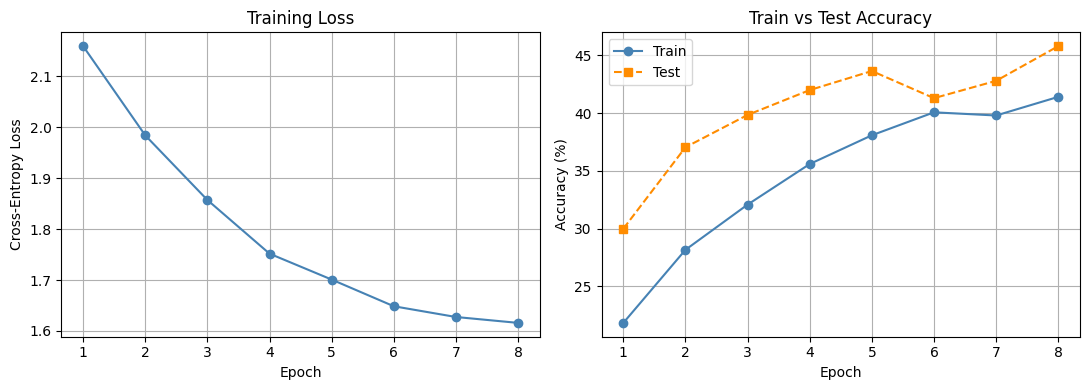

Gap between train and test accuracy = sign of overfitting


In [74]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(range(1, EPOCHS+1), train_losses, 'o-', color='steelblue')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training Loss'); ax1.grid(True)

ax2.plot(range(1, EPOCHS+1), [a*100 for a in train_accs], 'o-', label='Train', color='steelblue')
ax2.plot(range(1, EPOCHS+1), [a*100 for a in test_accs],  's--', label='Test',  color='darkorange')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Train vs Test Accuracy'); ax2.legend(); ax2.grid(True)

plt.tight_layout(); plt.show()
print("Gap between train and test accuracy = sign of overfitting")

---
## Step 8 — Visualise Predictions

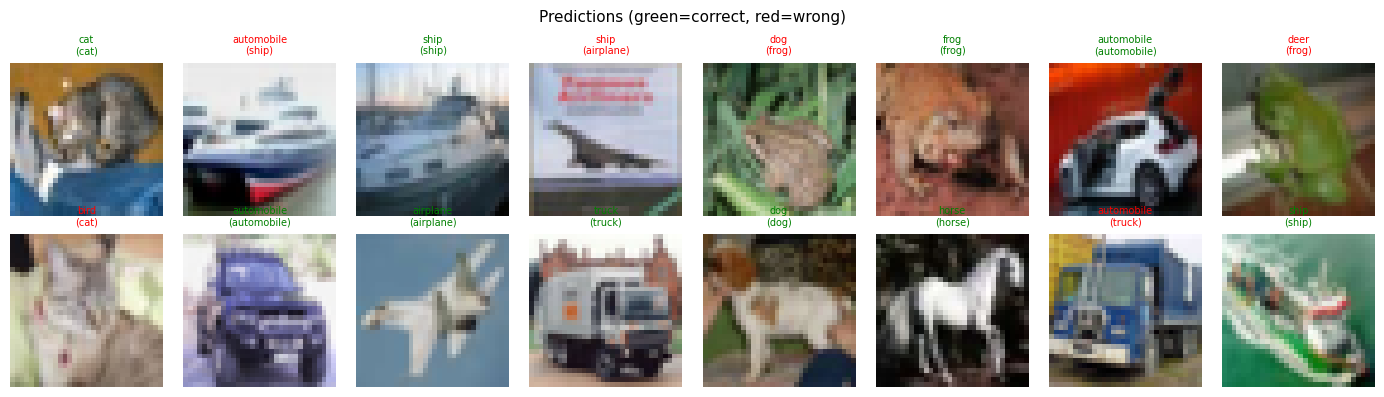

In [75]:
model.eval()
x_vis, y_vis = next(iter(test_loader))
x_vis = x_vis[:16].to(device)

with torch.no_grad():
    preds = model(x_vis).argmax(1)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(16):
    ax = axes[i // 8, i % 8]
    img = denorm(x_vis[i].cpu()).permute(1, 2, 0).numpy()
    ax.imshow(img)
    true_label = CLASSES[y_vis[i].item()]
    pred_label = CLASSES[preds[i].item()]
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"{pred_label}\n({true_label})", fontsize=7, color=color)
    ax.axis('off')
plt.suptitle('Predictions (green=correct, red=wrong)', fontsize=11)
plt.tight_layout(); plt.show()

---
## Step 9 — Experiment: Change One Thing

✏️ **Your job:** Go back to Step 4 and change `OUT1`, `OUT2`, `K1`, or `K2`.  
Re-run from Step 4 onward (you do NOT need to re-download data).

| OUT1 | OUT2 | K1 | K2 | LR | Final test acc (%) | Train > Test gap? |
|---|---|---|---|---|---|---|
| 32 | 64 | 3 | 3 | 1e-3 | | |
| ??? | ??? | ??? | ??? | ??? | | |

**Questions to discuss:**
- Does doubling `OUT1`/`OUT2` improve accuracy? At what cost (parameters, time)?  
- What happens if `K1 = K2 = 5` (larger kernels)?  
- The train accuracy is higher than test accuracy. What does this gap indicate?  
- A random classifier on 10 classes would get 10%. Your model gets ___ %. How many times better is that?

In [9]:
# ✏️ Record your experiment results here as comments
# OUT1=32, OUT2=64, K1=3, K2=3, LR=1e-3  → test acc = ???
# OUT1=???, ...                           → test acc = ???
print("Record observations above, then prepare your whiteboard lecture.")

Record observations above, then prepare your whiteboard lecture.


---
## Step 10 — Whiteboard Lecture Prep (10 minutes)

Use the **front board (left half)** and structure your lecture as follows.  
Take a photo to submit.

---

### 🖊️ Whiteboard Template — CNN

**1. Problem Statement & Data** (2 min)  
- Task: 10-class image classification  
- CIFAR-10: 60,000 images, 32×32 RGB, 10 classes — list them  
- Why is this harder than MNIST? (colour, clutter, viewpoint variation)

**2. Architecture Diagram** (3 min)  
Draw with shapes at each stage:
```
(3×32×32) → Conv(3→OUT1, K×K) → ReLU → MaxPool → (OUT1×16×16)
           → Conv(OUT1→OUT2, K×K) → ReLU → MaxPool → (OUT2×8×8)
           → Flatten → FC(OUT2·64, 256) → ReLU → Dropout → FC(256,10)
```
Label: filters, receptive field, parameter sharing, why MaxPool shrinks dimensions.

**3. Key Hyperparameter Choices** (3 min)  
- `OUT1`, `OUT2`: depth of feature maps — what did you try?  
- `kernel_size`: what patch does each filter see?  
- `Dropout(0.4)`: what does this regularise?  
- `learning_rate`: what happened if you changed it?  

**4. Results** (2 min)  
- Final test accuracy (%)  
- Train vs test gap — is the model overfitting?  
- Baseline comparison: random = 10%, your model = ___%  
- What classes are hardest to classify, and why? (cat/dog confusion is famous)